# Structural Vibration Analysis
## Full pipeline: load → signals → FFT → FDD modal identification

This notebook analyzes sensor data from `Raw_Data/` step by step.

| Step | Description |
|------|-------------|
| 1 | Setup & base functions |
| 2 | Load and explore a `.bin` file |
| 3 | Plot signals in the time domain |
| 4 | FFT analysis per channel |
| 5 | FDD — natural frequency identification |
| 6 | Compare headers across all sensors |
| 7 | Multi-sensor FDD || 8 | Export to MATLAB (.mat) |


## Step 1 — Libraries and base functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from scipy.signal import csd
from scipy.fft import rfft, rfftfreq
from scipy.io import savemat
from numpy.linalg import svd

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [3]:
DATA_DIR = r"C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Raw_Data\class10june"

# =========================
# 1. 24-bit Decoder
# =========================
def read_int24_le(data):
    b = np.frombuffer(data, dtype=np.uint8).reshape(-1, 3)
    vals = (b[:,0].astype(np.int32) |
           (b[:,1].astype(np.int32) << 8) |
           (b[:,2].astype(np.int32) << 16))
    # Sign extension
    mask = 1 << 23
    return (vals ^ mask) - mask

# =========================
# 2. Load file
# =========================
def load_file(filename):
    with open(filename, "rb") as f:
        data = f.read()

    # Find header
    header_end = data.find(b"\r\n\r\n") + 4
    header = data[:header_end].decode("ascii", errors="ignore")
    binary = data[header_end:]

    # Extract sampling rate
    fs = None
    for line in header.splitlines():
        if "Sampling Frequency" in line:
            fs = float(line.split(":")[1])

    if fs is None:
        raise ValueError(f"Sampling rate not found in {filename}")

    # Decode data
    values = read_int24_le(binary)
    n = (len(values) // 6) * 6
    samples = values[:n].reshape(-1, 6)
    df = pd.DataFrame(samples, columns=["Vx","Vy","Vz","Ax","Ay","Az"])
    return df, fs, header

# =========================
# 3. Read header
# =========================
def read_header(filename):
    with open(filename, "rb") as f:
        data = f.read()
    end = data.find(b"\r\n\r\n") + 4
    return data[:end].decode("ascii", errors="ignore")

def parse_header(header):
    info = {}
    for line in header.splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            info[key.strip()] = value.strip()
    return info

print("Base functions defined.")

Base functions defined.


## Step 2 — Load a file and explore its contents

In [4]:
# List available files
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".bin")])
print("Files found:")
for f in files:
    size_kb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

Files found:
  Setup1_sensor1.bin  (149814.0 KB)
  Setup1_sensor2.bin  (149814.0 KB)
  Setup1_sensor3.bin  (149814.0 KB)
  Setup1_sensor4.bin  (149814.0 KB)
  Setup1_sensor5.bin  (149814.0 KB)
  Setup1_sensor6.bin  (149814.0 KB)


In [5]:
# Load the first sensor file
SENSOR_FILE = os.path.join(DATA_DIR, files[0])

df, fs, header = load_file(SENSOR_FILE)

print(f"File        : {SENSOR_FILE}")
print(f"Fs          : {fs} Hz")
print(f"Samples     : {len(df)}")
print(f"Duration    : {len(df)/fs:.1f} s")
print(f"\nHeader:\n{header}")

File        : Raw_Data\Setup1_sensor1.bin
Fs          : 1183.712158 Hz
Samples     : 8522727
Duration    : 7200.0 s

Header:
Battery (%,mV,mA): 92.5,4048,-189 
Temperature (C): 26.5 
Start: Date 2026/05/12 Time 09:48:49 
Duration (minutes): 120 
Sampling Frequency (Hz): 1183.712158 
Number of Samples: 8522727 
Synchronization Mode: Radio 
Velocity Gain: 1 
Full Scale Range: 2g 
Geophone: 27.75,0.699998,4.489995,27.079999,0.680000,4.329998,27.850000,0.689997,4.579998 
Project: M7 
Setup: 1 
Sensor ID: 1 
Serial Number: W0228L 
Generation: 2 
Vx Vy Vz Ax Ay Az 




In [6]:
# Preview first rows
df.head(10)

,Vx,Vy,Vz,Ax,Ay,Az
0,-473044,-278501,-644995,16364,13422,270854
1,-471652,-273362,-653790,16016,14021,271211
2,-470748,-267278,-661685,16169,14612,271957
3,-469686,-260624,-669500,16009,15453,271799
4,-469271,-253718,-676458,15715,15825,272293
5,-469220,-247062,-683393,15514,16358,272234
6,-469283,-240635,-689689,14936,16767,272355
7,-469977,-234256,-694490,14313,16504,272304
8,-470943,-228299,-697966,13951,16564,272746
9,-471562,-222522,-700506,13808,16028,272020


In [7]:
# Basic statistics
df.describe()

,Vx,Vy,Vz,Ax,Ay,Az
count,8.522727e+06,8.522727e+06,8.522727e+06,8.522727e+06,8.522727e+06,8.522727e+06
mean,-4.295033e+01,-1.570628e+01,1.563450e+01,-1.195302e+03,-2.579805e+03,2.585494e+05
std,7.150375e+04,6.879189e+04,1.551049e+05,6.137064e+03,6.800050e+03,6.237373e+03
min,-2.848780e+06,-2.941782e+06,-4.767033e+06,-5.242870e+05,-4.895170e+05,-4.834340e+05
25%,-2.670000e+02,-3.440000e+02,-1.830000e+02,-1.961000e+03,-4.040000e+03,2.585330e+05
50%,-3.700000e+01,-7.000000e+00,2.500000e+01,-1.877000e+03,-3.965000e+03,2.586410e+05
75%,1.940000e+02,3.270000e+02,2.350000e+02,-1.703000e+03,-3.784000e+03,2.587510e+05
max,3.321144e+06,8.388607e+06,8.388607e+06,5.242870e+05,5.242870e+05,5.242870e+05


## Step 3 — Time-domain signals

- **Vx, Vy, Vz** → velocity
- **Ax, Ay, Az** → acceleration

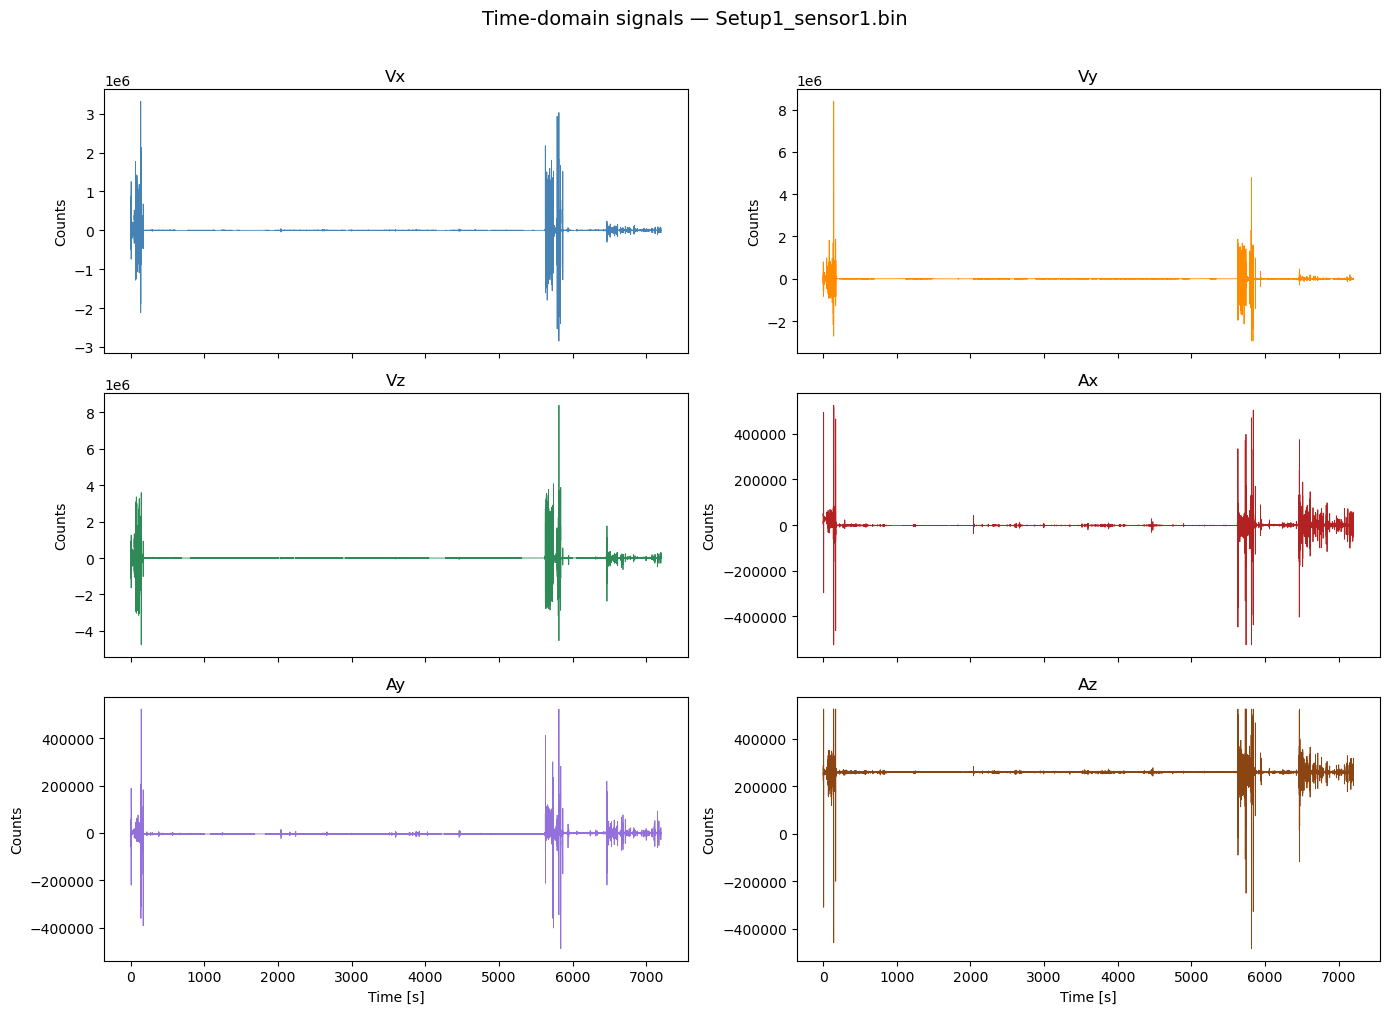

In [8]:
t = np.arange(len(df)) / fs

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick', 'mediumpurple', 'saddlebrown']

for ax, col, color in zip(axes.flat, df.columns, colors):
    ax.plot(t, df[col], color=color, linewidth=0.6)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel("Counts")

axes[-1, 0].set_xlabel("Time [s]")
axes[-1, 1].set_xlabel("Time [s]")
fig.suptitle(f"Time-domain signals — {files[0]}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Step 4 — FFT Analysis

Amplitude spectrum computed per channel. X-axis limited to **0–100 Hz**.

In [9]:
# =========================
# 3. FFT Analysis
# =========================
def compute_fft(signal, fs):
    N = len(signal)
    f = rfftfreq(N, 1/fs)
    spectrum = np.abs(rfft(signal)) / N
    return f, spectrum

# =========================
# 4. Find dominant frequency
# =========================
def dominant_frequency(signal, fs, fmin=0.5, fmax=100):
    f, spec = compute_fft(signal, fs)
    mask = (f >= fmin) & (f <= fmax)
    f_sel, spec_sel = f[mask], spec[mask]
    idx = np.argmax(spec_sel)
    return f_sel[idx], spec_sel[idx]

# =========================
# 5. Compute RMS
# =========================
def rms(x):
    return np.sqrt(np.mean(x**2))

# =========================
# 6. Run analysis
# =========================
print("\n=== Channel summary ===")
summary = []
for col in df.columns:
    sig = df[col].values - np.mean(df[col].values)
    r = rms(sig)
    f_dom, amp = dominant_frequency(sig, fs)
    summary.append({"Channel": col, "RMS": round(r, 2), "Dominant Frequency [Hz]": round(f_dom, 3), "Amplitude": round(amp, 2)})

pd.DataFrame(summary).set_index("Channel")


=== Channel summary ===


,RMS,Dominant Frequency [Hz],Amplitude
Channel,,,
Vx,71503.74,1.741,912.76
Vy,68791.89,1.625,811.88
Vz,155104.84,1.793,3896.41
Ax,6137.06,0.795,48.16
Ay,6800.05,0.884,48.78
Az,6237.37,1.793,178.70


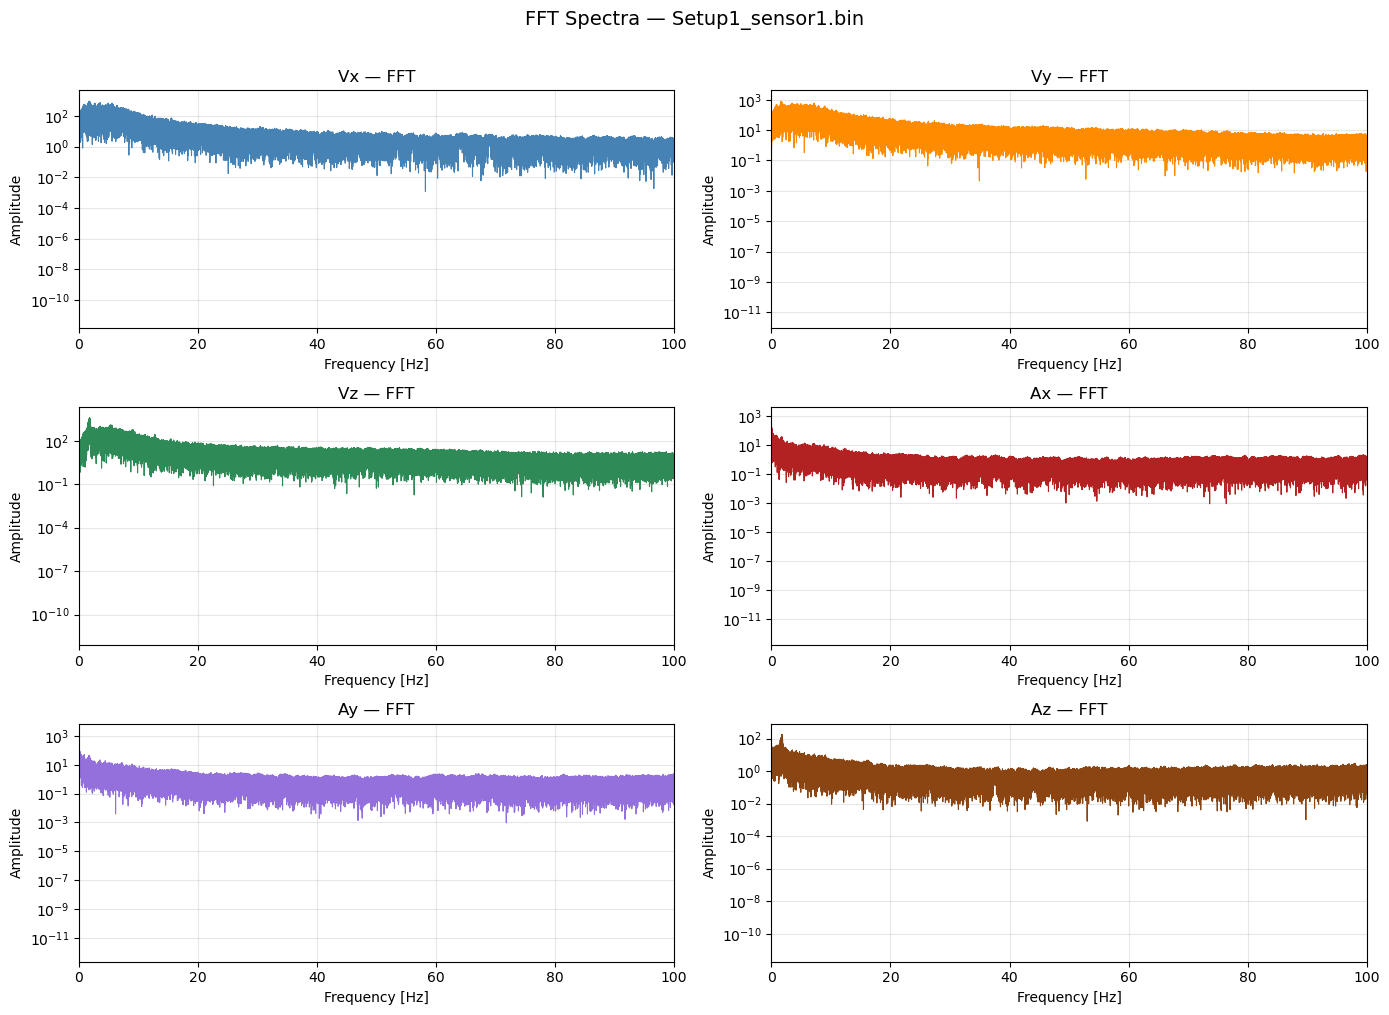

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flat, df.columns, colors):
    sig = df[col].values - np.mean(df[col].values)
    f, spec = compute_fft(sig, fs)
    ax.semilogy(f, spec, color=color, linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.set_title(f"{col} — FFT", fontsize=12)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"FFT Spectra — {files[0]}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Step 5 — FDD (Frequency Domain Decomposition)

FDD decomposes the cross-spectral density matrix via SVD. **Peaks in the first singular value** correspond to the natural frequencies of the structure.

> Can be applied to all 3 acceleration channels (multi-channel) or any subset.

In [11]:
# =========================
# 1. FDD
# =========================
def compute_csd_matrix(data, fs, nperseg=4096):
    n_channels = data.shape[1]
    S = []
    for i in range(n_channels):
        row = []
        for j in range(n_channels):
            f, Pxy = csd(data[:,i], data[:,j], fs=fs, nperseg=nperseg)
            row.append(Pxy)
        S.append(row)
    S = np.array(S)                    # (ch, ch, freq)
    S = np.transpose(S, (2, 0, 1))    # → (freq, ch, ch)
    return f, S

def fdd(data, fs):
    freqs, S = compute_csd_matrix(data, fs)
    sv_list, U_list = [], []
    for k in range(len(freqs)):
        U, s, _ = svd(S[k,:,:])
        sv_list.append(s)
        U_list.append(U)
    return freqs, np.array(sv_list), np.array(U_list)

# =========================
# 2. Find peaks
# =========================
def find_peaks(freqs, sv, fmin=1, fmax=50, threshold=0.1):
    s1 = sv[:,0].real
    mask = (freqs > fmin) & (freqs < fmax)
    f_sel, s_sel = freqs[mask], s1[mask]
    peaks = []
    for i in range(1, len(s_sel)-1):
        if s_sel[i] > s_sel[i-1] and s_sel[i] > s_sel[i+1]:
            if s_sel[i] > threshold * np.max(s_sel):
                peaks.append((f_sel[i], s_sel[i]))
    return peaks

print("FDD functions defined.")

FDD functions defined.


In [12]:
# Channels to analyze — change to ["Vx","Vy","Vz"] for velocity
CHANNELS = ["Ax", "Ay", "Az"]

data = df[CHANNELS].values.astype(float)
data -= np.mean(data, axis=0)  # remove DC offset

print(f"Running FDD on channels: {CHANNELS} ...")
freqs, sv, U = fdd(data, fs)
print("FDD done.")

Running FDD on channels: ['Ax', 'Ay', 'Az'] ...
FDD done.


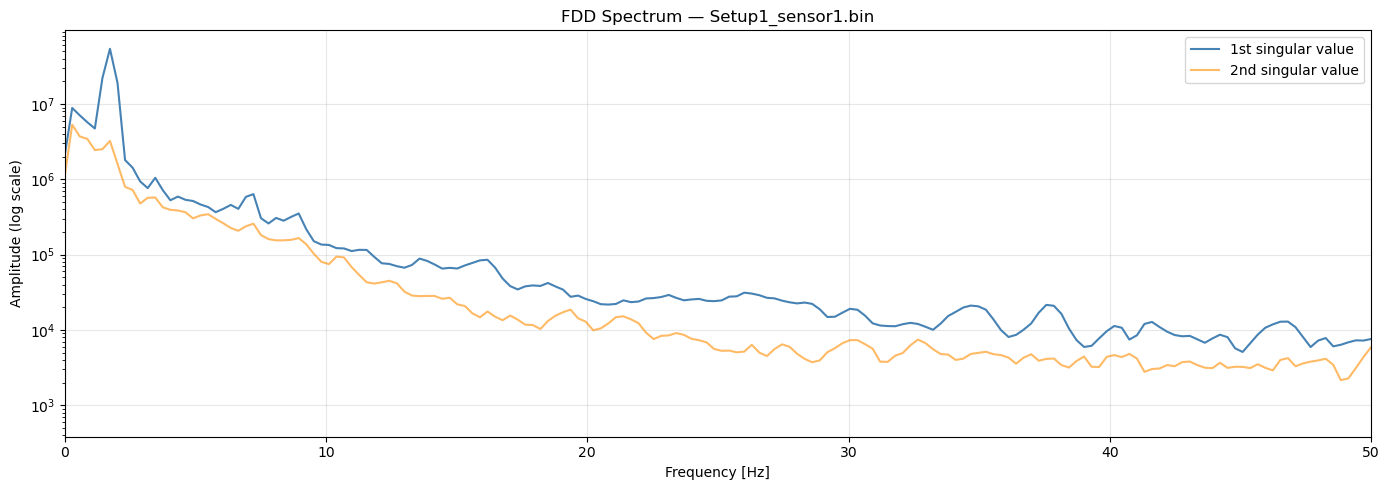

In [13]:
# =========================
# 4. Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(freqs, sv[:,0].real, label="1st singular value", color="steelblue")
if sv.shape[1] > 1:
    ax.semilogy(freqs, sv[:,1].real, label="2nd singular value", color="darkorange", alpha=0.6)
ax.set_xlim(0, 50)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude (log scale)")
ax.set_title(f"FDD Spectrum — {files[0]}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Detected natural frequencies:


,Frequency [Hz],Amplitude
0,1.734,5.4150e+07


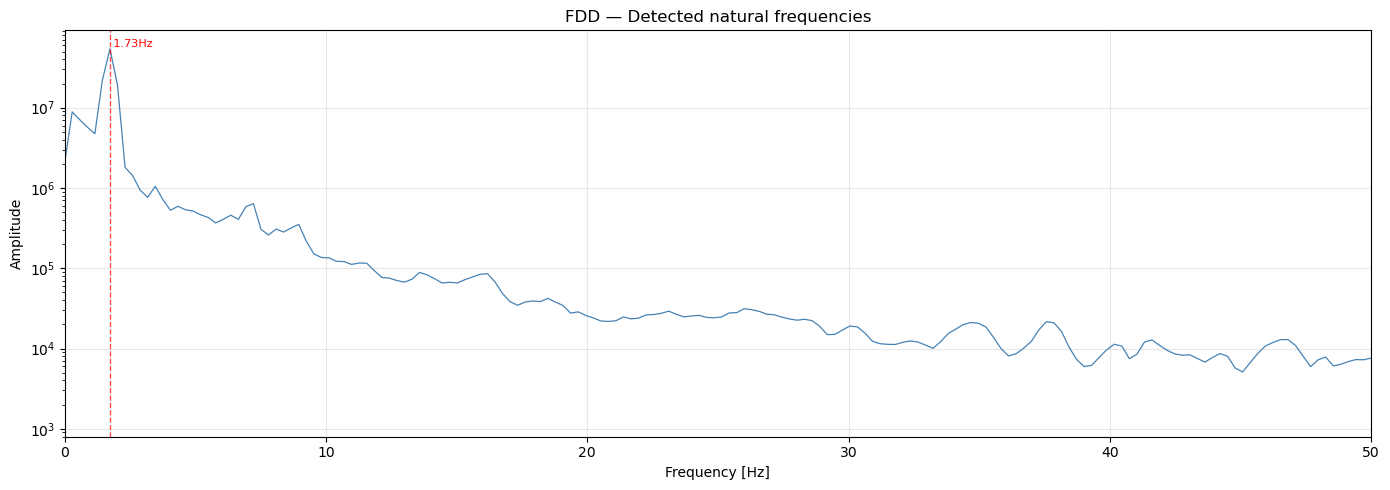

In [14]:
# Automatic peak detection
peaks = find_peaks(freqs, sv, fmin=1, fmax=50, threshold=0.1)

print("Detected natural frequencies:")
peak_df = pd.DataFrame(peaks, columns=["Frequency [Hz]", "Amplitude"])
peak_df["Frequency [Hz]"] = peak_df["Frequency [Hz]"].round(3)
peak_df["Amplitude"] = peak_df["Amplitude"].apply(lambda x: f"{x:.4e}")
display(peak_df)

# Mark peaks on the plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(freqs, sv[:,0].real, color="steelblue", linewidth=0.9)
for fp, amp in peaks:
    ax.axvline(fp, color="red", linewidth=1, linestyle="--", alpha=0.7)
    ax.text(fp, amp, f" {fp:.2f}Hz", fontsize=8, color="red", va="bottom")
ax.set_xlim(0, 50)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude")
ax.set_title("FDD — Detected natural frequencies")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# =========================
# 3. Extract mode shapes
# =========================
print("Mode shapes (first singular vector):")
for fp, _ in peaks:
    idx = np.argmin(np.abs(freqs - fp))
    mode = U[idx][:,0].real
    print(f"\n  Mode at {fp:.3f} Hz:  {dict(zip(CHANNELS, mode.round(4)))}")

Mode shapes (first singular vector):

  Mode at 1.734 Hz:  {'Ax': np.float64(-0.086), 'Ay': np.float64(0.1775), 'Az': np.float64(0.4323)}


## Step 6 — Compare headers across all sensors

Useful to verify that all sensors share the same configuration (Fs, gain, etc.).

In [16]:
rows = []
for f in files:
    header = read_header(os.path.join(DATA_DIR, f))
    parsed = parse_header(header)
    parsed["File"] = f
    rows.append(parsed)

header_df = pd.DataFrame(rows).set_index("File")
header_df

,"Battery (%,mV,mA)",Temperature (C),Start,Duration (minutes),Sampling Frequency (Hz),Number of Samples,Synchronization Mode,Velocity Gain,Full Scale Range,Geophone,Project,Setup,Sensor ID,Serial Number,Generation
File,,,,,,,,,,,,,,,
Setup1_sensor1.bin,"92.5,4048,-189",26.5,Date 2026/05/12 Time 09:48:49,120,1183.712158,8522727,Radio,1,2g,"27.75,0.699998,4.489995,27.079999,0.680000,4.3...",M7,1,1,W0228L,2
Setup1_sensor2.bin,"89.5,4044,-162",26.8,Date 2026/05/12 Time 09:48:49,120,1183.712158,8522727,Radio,1,2g,"27.450000,0.699998,4.449998,27.159999,0.670000...",M7,1,2,W0227L,2
Setup1_sensor3.bin,"95.4,4088,-158",26.5,Date 2026/05/12 Time 09:48:49,120,1183.712158,8522727,Radio,1,2g,"28.319999,0.699998,4.760000,27.260000,0.689998...",M7,1,3,W0219L,2
Setup1_sensor4.bin,"93.3,4072,-156",26.6,Date 2026/05/12 Time 09:48:49,120,1183.712158,8522727,Radio,1,2g,"27.159999,0.699998,4.349997,27.659999,0.689997...",M7,1,4,W0226L,2
Setup1_sensor5.bin,"92.1,4050,-159",26.5,Date 2026/05/12 Time 09:48:49,120,1183.712158,8522727,Radio,1,2g,"28,0.600000,4.5,28.517520,0.676669,4.539258,29...",M7,1,5,W0122L,2
Setup1_sensor6.bin,"95.0,4088,-155",26.8,Date 2026/05/12 Time 09:48:49,120,1183.712158,8522727,Radio,1,2g,"27,0.689999,4.5,27.469999,0.699999,4.369999,27...",M7,1,6,W0215L,2


In [17]:
# =========================
# 5. Highlight differences
# =========================
def highlight_diff(col):
    ref = col.iloc[0]
    return ["background-color: #ffcccc" if v != ref else "" for v in col]

styled = header_df.style.apply(highlight_diff, axis=0)
styled

AttributeError: The '.style' accessor requires jinja2

## Step 7 (optional) — Multi-sensor FDD

Combine one channel from all sensors to obtain spatially distributed mode shapes.

In [ ]:
# =========================
# 5. MAIN (multi-sensor)
# =========================
# Channel to use from each sensor
CHANNEL = "Az"

signals = []
for fname in files:
    df_s, fs_s, _ = load_file(os.path.join(DATA_DIR, fname))
    sig = df_s[CHANNEL].values.astype(float)
    sig -= sig.mean()
    signals.append(sig)

# Trim to minimum common length
min_len = min(len(s) for s in signals)
data_multi = np.column_stack([s[:min_len] for s in signals])

print(f"Multi-sensor matrix: {data_multi.shape}  (samples × sensors)")

freqs_m, sv_m, U_m = fdd(data_multi, fs_s)
peaks_m = find_peaks(freqs_m, sv_m, fmin=1, fmax=50, threshold=0.1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(freqs_m, sv_m[:,0].real, color="steelblue")
for fp, amp in peaks_m:
    ax.axvline(fp, color="red", linewidth=1, linestyle="--", alpha=0.7)
    ax.text(fp, amp, f" {fp:.2f}Hz", fontsize=8, color="red")
ax.set_xlim(0, 50)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude")
ax.set_title(f"Multi-sensor FDD ({len(files)} sensors, channel {CHANNEL})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNatural frequencies (multi-sensor):")
for fp, _ in peaks_m:
    idx = np.argmin(np.abs(freqs_m - fp))
    mode = U_m[idx][:,0].real
    mode_norm = mode / np.max(np.abs(mode))
    print(f"  {fp:.3f} Hz → mode shapes: {mode_norm.round(3)}")

## Step 8 — Export to MATLAB (.mat)

Batch-converts all `.bin` files from `Raw_Data/class10june/` to `.mat` files saved in `Post_Process_Data/`.  
Each `.mat` file contains: `data` (N×6 matrix), `columns` (channel names), `fs` (sampling rate), `header` (raw header string).

In [ ]:
POST_DIR = r"C:\Users\verwalter\Desktop\Cesar\Sensequake\PythonScripts\Post_Process_Data"
os.makedirs(POST_DIR, exist_ok=True)

export_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".bin")])
print(f"Found {len(export_files)} .bin files to export...")

for fname in export_files:
    fpath = os.path.join(DATA_DIR, fname)
    df_exp, fs_exp, hdr_exp = load_file(fpath)
    stem = os.path.splitext(fname)[0]
    
    # Export to MAT
    out_path_mat = os.path.join(POST_DIR, stem + ".mat")
    savemat(out_path_mat, {
        "data":    df_exp.values,
        "columns": df_exp.columns.tolist(),
        "fs":      fs_exp,
        "header":  hdr_exp
    })
    
    # Export to CSV
    out_path_csv = os.path.join(POST_DIR, stem + ".csv")
    df_exp.to_csv(out_path_csv, index=False)
    
    # Export to Pickle (Python)
    out_path_pkl = os.path.join(POST_DIR, stem + ".pkl")
    df_exp.to_pickle(out_path_pkl)
    
    # Export to NPZ (NumPy)
    out_path_npz = os.path.join(POST_DIR, stem + ".npz")
    np.savez(out_path_npz, data=df_exp.values, fs=fs_exp, columns=df_exp.columns.tolist())
    
    print(f"  Exported: {stem}.{{mat,csv,pkl,npz}}")

print(f"\nDone. {len(export_files)} file(s) exported in 4 formats to: {POST_DIR}")
